In [2]:
import os
import shutil
import random

# ── CONFIG ──
DATASET_PATH = r'D:\6th Sem\Project - II\PlantVillage\PlantVillage'
OUTPUT_PATH  = r'D:\6th Sem\Project - II\dataset'
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15
RANDOM_SEED  = 42

random.seed(RANDOM_SEED)

class_names = sorted(os.listdir(DATASET_PATH))

print(f'Classes found: {len(class_names)}')
print('-' * 50)

for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)

    n       = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = {
        'train': images[:n_train],
        'val'  : images[n_train:n_train + n_val],
        'test' : images[n_train + n_val:]
    }

    for split, files in splits.items():
        dest = os.path.join(OUTPUT_PATH, split, cls)
        os.makedirs(dest, exist_ok=True)
        for fname in files:
            shutil.copy2(os.path.join(cls_path, fname),
                         os.path.join(dest, fname))

    print(f'{cls:<50} train={len(splits["train"]):>4}  '
          f'val={len(splits["val"]):>3}  test={len(splits["test"]):>3}')

print('\nDone! Dataset split complete.')


Classes found: 15
--------------------------------------------------
Pepper__bell___Bacterial_spot                      train= 697  val=149  test=151
Pepper__bell___healthy                             train=1034  val=221  test=223
Potato___Early_blight                              train= 700  val=150  test=150
Potato___Late_blight                               train= 700  val=150  test=150
Potato___healthy                                   train= 106  val= 22  test= 24
Tomato_Bacterial_spot                              train=1488  val=319  test=320
Tomato_Early_blight                                train= 700  val=150  test=150
Tomato_Late_blight                                 train=1336  val=286  test=287
Tomato_Leaf_Mold                                   train= 666  val=142  test=144
Tomato_Septoria_leaf_spot                          train=1239  val=265  test=267
Tomato_Spider_mites_Two_spotted_spider_mite        train=1173  val=251  test=252
Tomato__Target_Spot                     

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# Training generator — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation & Test — only rescale
val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    r'D:\6th Sem\Project - II\dataset\train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    r'D:\6th Sem\Project - II\dataset\val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    r'D:\6th Sem\Project - II\dataset\test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'Number of classes : {len(train_gen.class_indices)}')
print(f'Training images   : {train_gen.samples:,}')
print(f'Validation images : {val_gen.samples:,}')
print(f'Test images       : {test_gen.samples:,}')
print(f'\nClass Mapping:')
for cls, idx in sorted(train_gen.class_indices.items(), key=lambda x: x[1]):
    print(f'  {idx:>2}: {cls}')

Found 14440 images belonging to 15 classes.
Found 3089 images belonging to 15 classes.
Found 3109 images belonging to 15 classes.
Number of classes : 15
Training images   : 14,440
Validation images : 3,089
Test images       : 3,109

Class Mapping:
   0: Pepper__bell___Bacterial_spot
   1: Pepper__bell___healthy
   2: Potato___Early_blight
   3: Potato___Late_blight
   4: Potato___healthy
   5: Tomato_Bacterial_spot
   6: Tomato_Early_blight
   7: Tomato_Late_blight
   8: Tomato_Leaf_Mold
   9: Tomato_Septoria_leaf_spot
  10: Tomato_Spider_mites_Two_spotted_spider_mite
  11: Tomato__Target_Spot
  12: Tomato__Tomato_YellowLeaf__Curl_Virus
  13: Tomato__Tomato_mosaic_virus
  14: Tomato_healthy


In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, regularizers

NUM_CLASSES = 15
IMG_SHAPE   = (224, 224, 3)

# Load MobileNetV2 pretrained on ImageNet, without top classifier
base_model = MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# Freeze base model layers first
base_model.trainable = False

# Build full model
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='PlantDisease_MobileNetV2')

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "PlantDisease_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,051,087 (11.64 MB)

 Trainable params: 792,079 (3.02 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

In [6]:
import os

SAVE_DIR = r'D:\6th Sem\Project - II\saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, 'best_phase1.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Phase 1: Training classifier head (MobileNetV2 frozen)...")

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)

print("\nPhase 1 Training Complete!")
print(f"Best Validation Accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")

Phase 1: Training classifier head (MobileNetV2 frozen)...
Epoch 1/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 988ms/step - accuracy: 0.7156 - loss: 1.5323
Epoch 1: val_accuracy improved from None to 0.82454, saving model to D:\6th Sem\Project - II\saved_models\best_phase1.keras

Epoch 1: finished saving model to D:\6th Sem\Project - II\saved_models\best_phase1.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 524s 1s/step - accuracy: 0.7549 - loss: 1.3518 - val_accuracy: 0.8245 - val_loss: 1.0287 - learning_rate: 0.0010
Epoch 2/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - accuracy: 0.8057 - loss: 1.0540
Epoch 2: val_accuracy improved from 0.82454 to 0.87148, saving model to D:\6th Sem\Project - II\saved_models\best_phase1.keras

Epoch 2: finished saving model to D:\6th Sem\Project - II\saved_models\best_phase1.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 497s 1s/step - accuracy: 0.8139 - loss: 1.0035 - val_accuracy: 0.8715 - val_loss: 0.7942 - learning_rate: 0.0010
Epoch 3/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/st

In [2]:
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── CONFIG ──
SAVE_DIR   = r'D:\6th Sem\Project - II\saved_models'
IMG_SIZE   = (224, 224)
IMG_SHAPE  = (224, 224, 3)
BATCH_SIZE = 32
NUM_CLASSES = 15

# ── Reload Generators ──
val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

train_gen = train_datagen.flow_from_directory(
    r'D:\6th Sem\Project - II\dataset\train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    r'D:\6th Sem\Project - II\dataset\val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ── Rebuild Model ──
base_model = MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='PlantDisease_MobileNetV2')

# ── Load saved Phase 1 weights ──
model.load_weights(os.path.join(SAVE_DIR, 'best_phase1.keras'))

print("Model rebuilt and Phase 1 weights loaded successfully!")
print(f"Validation will start from 90.45% accuracy")



Found 14440 images belonging to 15 classes.
Found 3089 images belonging to 15 classes.
Model rebuilt and Phase 1 weights loaded successfully!
Validation will start from 90.45% accuracy


In [3]:
# Unfreeze top layers of MobileNetV2 for fine-tuning
base_model.trainable = True

# Freeze all layers before layer 100, unfreeze from 100 onwards
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with much lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable layers after unfreezing: "
      f"{sum(1 for l in model.layers if l.trainable)}")

callbacks_phase2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, 'best_phase2.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-8,
        verbose=1
    )
]

print("\nPhase 2: Fine-tuning top MobileNetV2 layers...")

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks_phase2
)

print("\nPhase 2 Training Complete!")
print(f"Best Validation Accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")

Trainable layers after unfreezing: 9

Phase 2: Fine-tuning top MobileNetV2 layers...
Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7188 - loss: 1.0446
Epoch 1: val_accuracy improved from None to 0.85562, saving model to D:\6th Sem\Project - II\saved_models\best_phase2.keras

Epoch 1: finished saving model to D:\6th Sem\Project - II\saved_models\best_phase2.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 931s 2s/step - accuracy: 0.7642 - loss: 0.8690 - val_accuracy: 0.8556 - val_loss: 0.6938 - learning_rate: 1.0000e-05
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8314 - loss: 0.6307
Epoch 2: val_accuracy improved from 0.85562 to 0.87925, saving model to D:\6th Sem\Project - II\saved_models\best_phase2.keras

Epoch 2: finished saving model to D:\6th Sem\Project - II\saved_models\best_phase2.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 921s 2s/step - accuracy: 0.8400 - loss: 0.6014 - val_accuracy: 0.8792 - val_loss: 0.5693 - learning_rate: 1.0000e-05
Epoch 3/10
452/452 ━━━

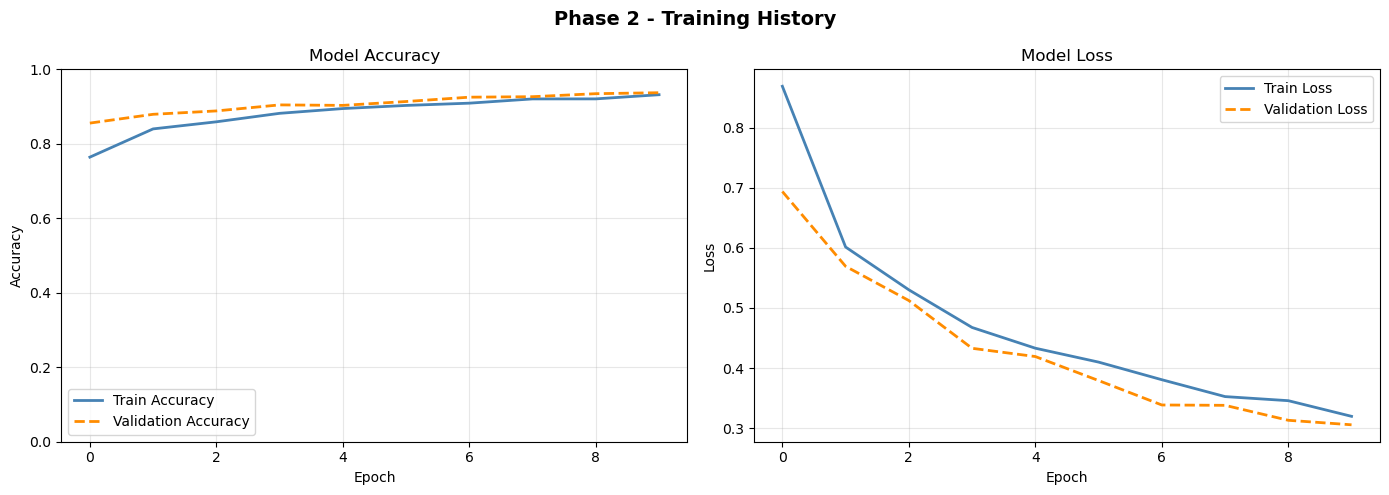

Graph saved!


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 2 - Training History', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(history2.history['accuracy'],     label='Train Accuracy',      color='steelblue',  lw=2)
axes[0].plot(history2.history['val_accuracy'], label='Validation Accuracy', color='darkorange', lw=2, linestyle='--')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Loss
axes[1].plot(history2.history['loss'],     label='Train Loss',      color='steelblue',  lw=2)
axes[1].plot(history2.history['val_loss'], label='Validation Loss', color='darkorange', lw=2, linestyle='--')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'D:\6th Sem\Project - II\training_graphs.png', dpi=120, bbox_inches='tight')
plt.show()
print("Graph saved!")

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Test generator
test_datagen = ImageDataGenerator(rescale=1.0/255)

test_gen = test_datagen.flow_from_directory(
    r'D:\6th Sem\Project - II\dataset\test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Evaluate
print("Evaluating on test set...")
test_loss, test_accuracy = model.evaluate(test_gen, verbose=1)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

Found 3109 images belonging to 15 classes.
Evaluating on test set...
98/98 ━━━━━━━━━━━━━━━━━━━━ 73s 749ms/step - accuracy: 0.9357 - loss: 0.2915

Test Loss     : 0.2915
Test Accuracy : 93.57%


In [6]:
import numpy as np
from sklearn.metrics import classification_report

# Get predictions
print("Generating predictions...")
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Class names
class_names = list(test_gen.class_indices.keys())

# Print report
print("\nClassification Report:")
print("=" * 70)
report = classification_report(y_true, y_pred, 
                                target_names=class_names, 
                                digits=4)
print(report)

# Save report
report_path = r'D:\6th Sem\Project - II\classification_report.txt'
with open(report_path, 'w') as f:
    f.write("PLANT DISEASE DETECTION - CLASSIFICATION REPORT\n")
    f.write("=" * 70 + "\n\n")
    f.write(report)

print(f"Report saved to {report_path}")


Generating predictions...
98/98 ━━━━━━━━━━━━━━━━━━━━ 52s 519ms/step

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9613    0.9868    0.9739       151
                     Pepper__bell___healthy     0.9780    0.9955    0.9867       223
                      Potato___Early_blight     0.9548    0.9867    0.9705       150
                       Potato___Late_blight     0.9571    0.8933    0.9241       150
                           Potato___healthy     0.8519    0.9583    0.9020        24
                      Tomato_Bacterial_spot     0.9659    0.9750    0.9705       320
                        Tomato_Early_blight     0.8837    0.7600    0.8172       150
                         Tomato_Late_blight     0.9236    0.9268    0.9252       287
                           Tomato_Leaf_Mold     0.9624    0.8889    0.9242       144
                  Tomato_Septoria_leaf_spot     0.9267   

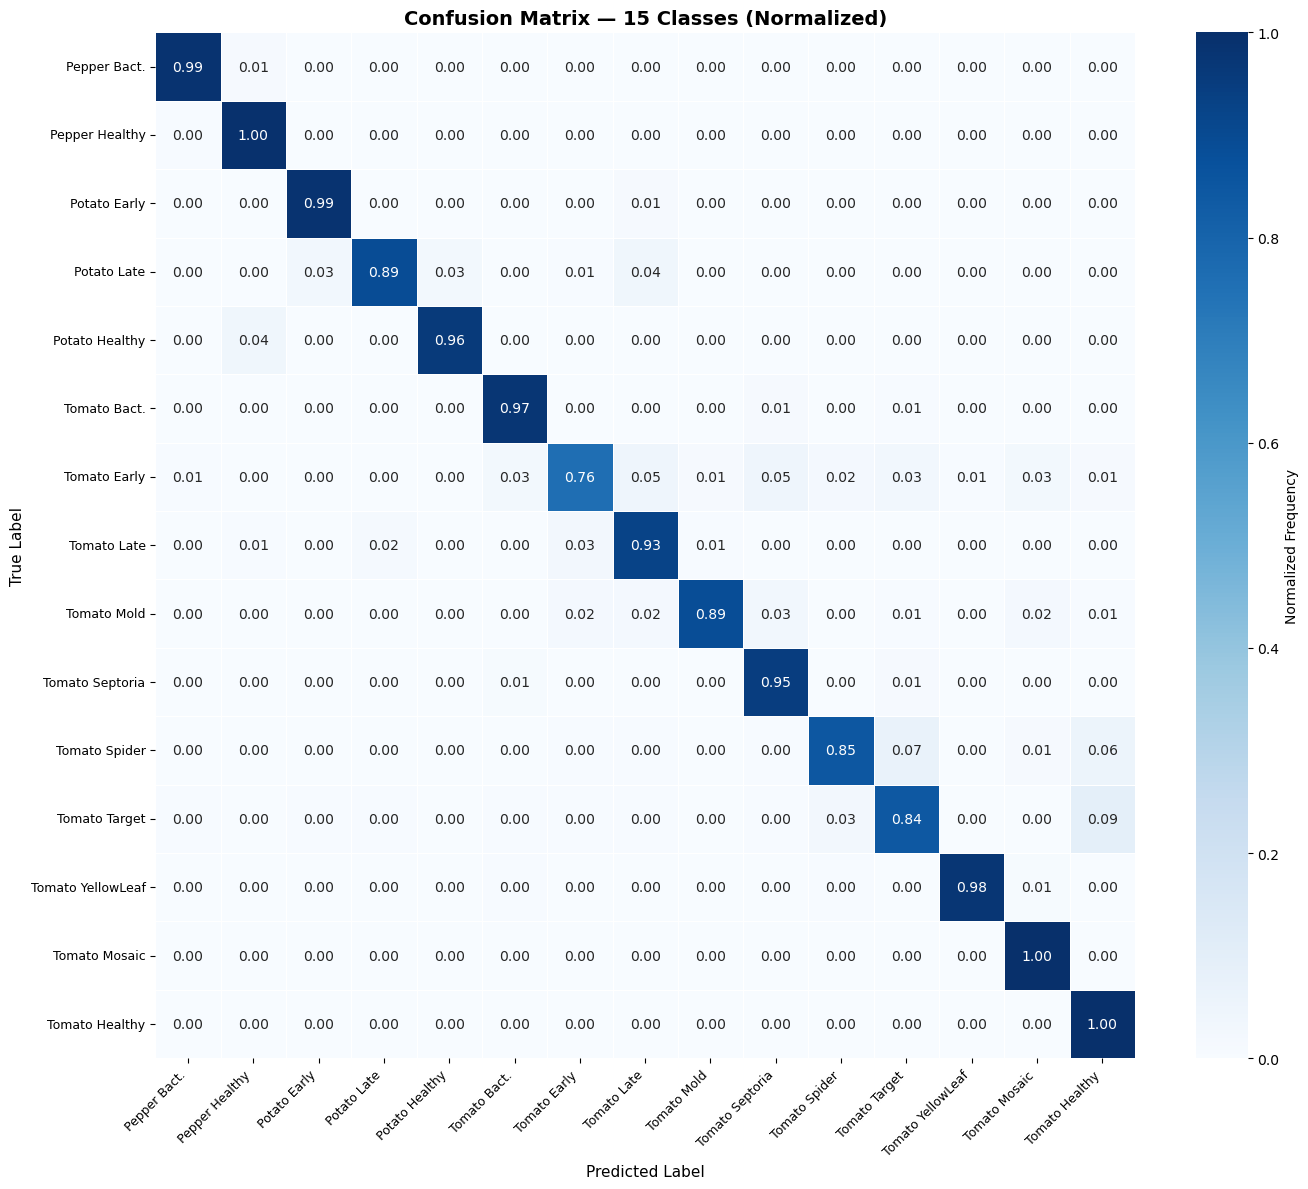

Confusion matrix saved!


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Build confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Short class names for display
short_names = [
    'Pepper Bact.', 'Pepper Healthy',
    'Potato Early', 'Potato Late', 'Potato Healthy',
    'Tomato Bact.', 'Tomato Early', 'Tomato Late',
    'Tomato Mold', 'Tomato Septoria', 'Tomato Spider',
    'Tomato Target', 'Tomato YellowLeaf', 'Tomato Mosaic',
    'Tomato Healthy'
]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, 
            annot=True, 
            fmt='.2f',
            xticklabels=short_names, 
            yticklabels=short_names,
            cmap='Blues',
            linewidths=0.5,
            cbar_kws={'label': 'Normalized Frequency'})

plt.title('Confusion Matrix — 15 Classes (Normalized)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(r'D:\6th Sem\Project - II\confusion_matrix.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

In [8]:
# Save final model
final_model_path = r'D:\6th Sem\Project - II\saved_models\plant_disease_final.keras'
model.save(final_model_path)

# Save class names
class_names_path = r'D:\6th Sem\Project - II\saved_models\class_names.txt'
with open(class_names_path, 'w') as f:
    for cls, idx in sorted(test_gen.class_indices.items(), key=lambda x: x[1]):
        f.write(f"{idx}: {cls}\n")

print("✅ Final model saved!")
print(f"   Model  → {final_model_path}")
print(f"   Classes → {class_names_path}")
print(f"\nModel Summary:")
print(f"   Total Classes    : 15")
print(f"   Test Accuracy    : 93.57%")
print(f"   Test Loss        : 0.2915")

✅ Final model saved!
   Model  → D:\6th Sem\Project - II\saved_models\plant_disease_final.keras
   Classes → D:\6th Sem\Project - II\saved_models\class_names.txt

Model Summary:
   Total Classes    : 15
   Test Accuracy    : 93.57%
   Test Loss        : 0.2915


In [9]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load class names
class_map = {}
with open(r'D:\6th Sem\Project - II\saved_models\class_names.txt', 'r') as f:
    for line in f:
        idx, cls = line.strip().split(': ', 1)
        class_map[int(idx)] = cls

def predict_leaf(image_path):
    img = load_img(image_path, target_size=(224, 224))
    arr = img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    preds = model.predict(arr, verbose=0)[0]
    top3  = preds.argsort()[-3:][::-1]

    print(f"\n🌿 Image: {image_path}")
    print("=" * 55)
    print(f"  {'Rank':<6} {'Class':<45} {'Confidence'}")
    print("-" * 55)
    for rank, idx in enumerate(top3, 1):
        cls  = class_map[idx]
        conf = preds[idx] * 100
        print(f"  #{rank:<5} {cls:<45} {conf:.2f}%")
    print("=" * 55)
    print(f"\n✅ Predicted: {class_map[top3[0]]} ({preds[top3[0]]*100:.2f}% confidence)")

# Predict using first image from Tomato Early Blight
predict_leaf(r'D:\6th Sem\Project - II\dataset\test\Tomato_Early_blight\04747279-48b2-4ce1-932b-e511424beb6b___RS_Erly.B 8240.JPG')


🌿 Image: D:\6th Sem\Project - II\dataset\test\Tomato_Early_blight\04747279-48b2-4ce1-932b-e511424beb6b___RS_Erly.B 8240.JPG
  Rank   Class                                         Confidence
-------------------------------------------------------
  #1     Tomato_Early_blight                           69.30%
  #2     Tomato_Septoria_leaf_spot                     21.04%
  #3     Tomato_Late_blight                            9.19%

✅ Predicted: Tomato_Early_blight (69.30% confidence)


In [2]:
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── CONFIG ──
SAVE_DIR    = r'D:\6th Sem\Project - II\saved_models'
IMG_SHAPE   = (224, 224, 3)
NUM_CLASSES = 15

# ── Rebuild Model ──
base_model = MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='PlantDisease_MobileNetV2')

# ── Load saved weights ──
model.load_weights(os.path.join(SAVE_DIR, 'best_phase2.keras'))

# ── Save weights only ──
weights_path = os.path.join(SAVE_DIR, 'plant_disease_weights.weights.h5')
model.save_weights(weights_path)

print("✅ Model rebuilt and weights saved!")
print(f"   Weights → {weights_path}")

✅ Model rebuilt and weights saved!
   Weights → D:\6th Sem\Project - II\saved_models\plant_disease_weights.weights.h5


In [1]:
import os
import shutil
import random

NEW_DATA_PATH = r"D:\6th Sem\Project - II\PlantVillage\New data"
OUTPUT_PATH   = r"D:\6th Sem\Project - II\dataset"
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
RANDOM_SEED   = 42

# ── Only these plants ──
INCLUDE_PLANTS = ['Jamun', 'lemon', 'Mango']

random.seed(RANDOM_SEED)

for plant_folder in os.listdir(NEW_DATA_PATH):
    if plant_folder not in INCLUDE_PLANTS:
        print(f"  Skipping: {plant_folder}")
        continue

    plant_path = os.path.join(NEW_DATA_PATH, plant_folder)

    for cls_folder in os.listdir(plant_path):
        cls_path = os.path.join(plant_path, cls_folder)
        if not os.path.isdir(cls_path):
            continue

        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)

        n       = len(images)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)

        splits = {
            'train': images[:n_train],
            'val'  : images[n_train:n_train + n_val],
            'test' : images[n_train + n_val:]
        }

        for split, files in splits.items():
            dest = os.path.join(OUTPUT_PATH, split, cls_folder)
            os.makedirs(dest, exist_ok=True)
            for fname in files:
                shutil.copy2(os.path.join(cls_path, fname),
                             os.path.join(dest, fname))

        print(f"{cls_folder:<45} train={len(splits['train']):>4}  "
              f"val={len(splits['val']):>3}  test={len(splits['test']):>3}")

print("\n✅ New data split complete!")

  Skipping: corn
Jamun___diseased                              train=1225  val=262  test=263
Jamun___healthy                               train=1225  val=262  test=263
Lemon___diseased                              train=1225  val=262  test=263
Lemon___healthy                               train=1225  val=262  test=263
Mango___diseased                              train=1225  val=262  test=263
Mango___Gall Midge                            train=1260  val=270  test=270
Mango___Healthy                               train=1260  val=270  test=270

✅ New data split complete!


In [2]:
import os

OUTPUT_PATH = r"D:\6th Sem\Project - II\dataset"

for split in ['train', 'val', 'test']:
    split_path = os.path.join(OUTPUT_PATH, split)
    classes = sorted(os.listdir(split_path))
    total = sum(len(os.listdir(os.path.join(split_path, c))) for c in classes)
    print(f"{split.upper():<6} — {len(classes)} classes — {total:,} images")

print(f"\nAll classes:")
for cls in sorted(os.listdir(os.path.join(OUTPUT_PATH, 'train'))):
    count = len(os.listdir(os.path.join(OUTPUT_PATH, 'train', cls)))
    print(f"  {cls:<50} {count:>5} images")
    

TRAIN  — 22 classes — 23,085 images
VAL    — 22 classes — 4,939 images
TEST   — 22 classes — 4,964 images

All classes:
  Jamun___diseased                                    1225 images
  Jamun___healthy                                     1225 images
  Lemon___diseased                                    1225 images
  Lemon___healthy                                     1225 images
  Mango___Gall Midge                                  1260 images
  Mango___Healthy                                     1260 images
  Mango___diseased                                    1225 images
  Pepper__bell___Bacterial_spot                        697 images
  Pepper__bell___healthy                              1034 images
  Potato___Early_blight                                700 images
  Potato___Late_blight                                 700 images
  Potato___healthy                                     106 images
  Tomato_Bacterial_spot                               1488 images
  Tomato_Early_blight 

In [1]:
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── CONFIG ──
SAVE_DIR    = r'D:\6th Sem\Project - II\saved_models'
IMG_SIZE    = (224, 224)
IMG_SHAPE   = (224, 224, 3)
BATCH_SIZE  = 32
NUM_CLASSES = 22

# ── Data Generators ──
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    r'D:\6th Sem\Project - II\dataset\train',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)
val_gen = val_test_datagen.flow_from_directory(
    r'D:\6th Sem\Project - II\dataset\val',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print(f"Classes : {train_gen.num_classes}")
print(f"Train   : {train_gen.samples:,}")
print(f"Val     : {val_gen.samples:,}")

# ── Rebuild Model with 22 output classes ──
base_model = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

inputs  = tf.keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation='relu',
                        kernel_regularizer=regularizers.l2(0.001))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model   = tf.keras.Model(inputs, outputs, name='PlantDisease_v2')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel built successfully!")
print(f"Output classes: {NUM_CLASSES}")

Found 23085 images belonging to 22 classes.
Found 4939 images belonging to 22 classes.
Classes : 22
Train   : 23,085
Val     : 4,939

Model built successfully!
Output classes: 22


In [2]:
callbacks_v2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, 'best_v2.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Training new model on 22 classes...")

history_v2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks_v2
)

print("\nTraining Complete!")
print(f"Best Validation Accuracy: {max(history_v2.history['val_accuracy'])*100:.2f}%")

Training new model on 22 classes...
Epoch 1/20
 64/722 ━━━━━━━━━━━━━━━━━━━━ 20:55 2s/step - accuracy: 0.4074 - loss: 2.9213

KeyboardInterrupt: 